# 297 nm single-photon CZ comparison

This notebook is a compact report, not an optimizer scratchpad. It compares the fixed first-pass 297 nm CZ operating point against the existing seven-level time-optimal and `find_phase` adiabatic baselines.

Fixed 297 baseline: `P_297 = 0.56 W` at the atoms, `beam_area = 420 um^2`, `B = 100 G`, `nP = 53P3/2`, `spacing = 3 um`. The primary metric is coherent CZ infidelity after manual local-Z phase projection from the logical overlaps `u00, u01, u10, u11`, plus a trajectory-integrated loss budget.

In [6]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-ryd-gate')

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

try:
    import pandas as pd
except ModuleNotFoundError:
    pd = None

try:
    from IPython.display import display
except ModuleNotFoundError:
    display = print

import ryd_gate as rg
from ryd_gate import Register, RydbergSystem
from ryd_gate.gates import (
    CZProtocol,
    TOProtocol,
    cz_gate_report,
    phase_from_chirp,
)
from ryd_gate.protocols import Direct297CZProtocol, Direct297TOProtocol
from ryd_gate.analysis import gate_metrics
from ryd_gate.analysis.gate_metrics import (
    error_budget_297,
    population_evolution_297,
)
from ryd_gate.physics import direct_297_rabis, our_laser_rabis

MHz = 2.0 * np.pi * 1e6
us = 1e-6

SPACING_UM = 3.0
P297_W = 0.56
BEAM_AREA_UM2 = 420.0
B_FIELD_G = 100.0
RYD_LEVEL_297 = 53

T_AD = 1.0 * us
D_AMP = 20.0 * MHz
DELTA_CHIRP = 0.0

N_STEPS_TO = 200
N_STEPS_AD = 1000
N_STEPS_SCAN = 300

RUN_SCANS = True
RUN_297_OPT = False
RUN_DECAY_ON_SANITY = False

if pd is not None:
    pd.options.display.float_format = '{:.6e}'.format


def wrap_to_pi(angle):
    return float((float(angle) + np.pi) % (2.0 * np.pi) - np.pi)


## Fixed hardware point

The first table is a sanity check for the 297 laser power and magnetic splitting at the chosen operating point. `Delta_garb/Omega_garb` is not the final figure of merit, but it shows whether the garbage branch is parametrically off-resonant.

In [7]:
omega297, omega297_garb = direct_297_rabis(
    P297_W, BEAM_AREA_UM2, ryd_level=RYD_LEVEL_297
)

sys297 = (
    RydbergSystem.set_atom_level(
        'rb87_297_clock_4',
        enable_rydberg_decay=False,
        magnetic_field_G=B_FIELD_G,
        ryd_level=RYD_LEVEL_297,
    )
    .set_atom_geom(Register.chain(2, spacing_um=SPACING_UM))
)

sys297_decay = (
    RydbergSystem.set_atom_level(
        'rb87_297_clock_4',
        enable_rydberg_decay=True,
        magnetic_field_G=B_FIELD_G,
        ryd_level=RYD_LEVEL_297,
    )
    .set_atom_geom(Register.chain(2, spacing_um=SPACING_UM))
)

sanity_rows = [
    {
        'quantity': 'Omega_297 target / 2pi',
        'value_MHz': omega297 / MHz,
        'note': 'target 1 -> r Rabi at atoms',
    },
    {
        'quantity': 'Omega_297 garbage / 2pi',
        'value_MHz': omega297_garb / MHz,
        'note': '1 -> r_garb branch',
    },
    {
        'quantity': 'Delta_garb / 2pi',
        'value_MHz': sys297.meta('garb_zeeman_detuning') / MHz,
        'note': 'low-field clock-state excited Zeeman splitting',
    },
    {
        'quantity': '|Delta_garb| / Omega_garb',
        'value_MHz': abs(sys297.meta('garb_zeeman_detuning')) / omega297_garb,
        'note': 'dimensionless',
    },
    {
        'quantity': 'V_nn / 2pi',
        'value_MHz': sys297.meta('interaction_pairs')[0][2] / MHz,
        'note': '53P3/2 C6 at theta=pi/2, spacing=3 um',
    },
    {
        'quantity': '53P lifetime at 300 K',
        'value_MHz': 1.0 / sys297.meta('ryd_state_decay_rate') / us,
        'note': 'value shown in us, not MHz',
    },
]
sanity297 = pd.DataFrame(sanity_rows) if pd is not None else sanity_rows
sanity297


[{'quantity': 'Omega_297 target / 2pi',
  'value_MHz': np.float64(16.050585372334243),
  'note': 'target 1 -> r Rabi at atoms'},
 {'quantity': 'Omega_297 garbage / 2pi',
  'value_MHz': np.float64(9.266809785368244),
  'note': '1 -> r_garb branch'},
 {'quantity': 'Delta_garb / 2pi',
  'value_MHz': 186.6165988940921,
  'note': 'low-field clock-state excited Zeeman splitting'},
 {'quantity': '|Delta_garb| / Omega_garb',
  'value_MHz': np.float64(20.138170871786848),
  'note': 'dimensionless'},
 {'quantity': 'V_nn / 2pi',
  'value_MHz': -131.87307179191595,
  'note': '53P3/2 C6 at theta=pi/2, spacing=3 um'},
 {'quantity': '53P lifetime at 300 K',
  'value_MHz': 100.29191732695675,
  'note': 'value shown in us, not MHz'}]

## Pulse builders

The 297 adiabatic pulse uses a bare phase chirp. The seven-level adiabatic baseline follows `find_phase.ipynb`: smooth 420/1013 envelopes and the Stark-compensated 420 chirp.

In [8]:
OPTICS_LOSS = 0.8
DELTA_7 = 40.1e3 * MHz
omega420, omega1013 = our_laser_rabis(
    p420_w=6.0 * (1.0 - OPTICS_LOSS),
    p1013_w=100.0 * (1.0 - OPTICS_LOSS),
    beam_area=BEAM_AREA_UM2,
    ryd_level=70,
)


def make_297_adiabatic(t_gate=T_AD, d_amp=D_AMP, delta_chirp=DELTA_CHIRP, n_steps=N_STEPS_AD):
    """297 adiabatic CZ pulse: smootherstep envelope + bare cosine phase chirp."""

    def env(t, ramp=0.15):
        s = float(np.clip(t / t_gate, 0.0, 1.0))
        u = min(s, 1.0 - s)
        if u >= ramp:
            return 1.0
        u = float(np.clip(u / ramp, 0.0, 1.0))
        return 10.0 * u**3 - 15.0 * u**4 + 6.0 * u**5

    chirp = lambda t: -d_amp * np.cos(2.0 * np.pi * t / t_gate) + delta_chirp
    phi = phase_from_chirp(chirp, t_gate=t_gate, n_samples=4 * n_steps + 1)
    return Direct297CZProtocol(
        t_gate=t_gate,
        A_297=lambda s: env(float(np.clip(s, 0.0, 1.0)) * t_gate),
        phi_297=lambda s: phi(float(np.clip(s, 0.0, 1.0)) * t_gate),
        power_at_atoms_w=P297_W,
        beam_area_um2=BEAM_AREA_UM2,
        n_steps=n_steps,
    )


def make_7l_find_phase_adiabatic(t_gate=T_AD, d_amp=D_AMP, delta_chirp=DELTA_CHIRP, n_steps=N_STEPS_AD):
    """Seven-level find_phase adiabatic CZ pulse: smootherstep 420/1013 envelopes
    + Stark-compensated 420 cosine chirp."""

    def env(t, ramp):
        s = float(np.clip(t / t_gate, 0.0, 1.0))
        u = min(s, 1.0 - s)
        if u >= ramp:
            return 1.0
        u = float(np.clip(u / ramp, 0.0, 1.0))
        return 10.0 * u**3 - 15.0 * u**4 + 6.0 * u**5

    d1_nom = -(4.0 / 3.0) * omega420**2 / (4.0 * DELTA_7)
    dr_nom = -(omega1013**2) / (4.0 * DELTA_7)

    def A420_t(t):
        return env(float(np.clip(t, 0.0, t_gate)), ramp=0.15)

    def A1013_t(t):
        return env(float(np.clip(t, 0.0, t_gate)), ramp=0.05)

    def chirp_with_stark(t):
        a = A420_t(t)
        b = A1013_t(t)
        return -d_amp * np.cos(2.0 * np.pi * t / t_gate) + dr_nom * b * b - d1_nom * a * a + delta_chirp

    phi = phase_from_chirp(chirp_with_stark, t_gate=t_gate, n_samples=4 * n_steps + 1)
    return CZProtocol(
        t_gate=t_gate,
        A_420=lambda s: A420_t(float(np.clip(s, 0.0, 1.0)) * t_gate),
        phi_420=lambda s: phi(float(np.clip(s, 0.0, 1.0)) * t_gate),
        A_1013=lambda s: A1013_t(float(np.clip(s, 0.0, 1.0)) * t_gate),
        phi_1013=lambda s: 0.0,
        omega_420_max=omega420,
        omega_1013_max=omega1013,
        n_steps=n_steps,
    )


## Baselines

`297 TO seed` is intentionally unoptimized. It uses the same one-microsecond gate time as the adiabatic seed and is scored with the same manual local-Z phase projection as the other fixed pulses. This cell only builds systems and pulses; scoring and budgets follow in their own cells.

In [9]:
X_TO_DARK = [
    -0.6894097925886826,
    1.040962607910546,
    0.3277877211544321,
    1.5639989822346387,
    0.6689846026179691,
    1.3407418093368753,
]

sys7_to = (
    RydbergSystem.set_atom_level('rb87_7_mp', detuning_sign=1)
    .set_atom_geom(Register.chain(2, spacing_um=SPACING_UM))
)
proto7_to = TOProtocol(n_steps=N_STEPS_TO)

sys7_ad = (
    RydbergSystem.set_atom_level(
        'rb87_7_mp',
        detuning_sign=1,
        Delta_Hz=DELTA_7 / (2.0 * np.pi),
        magnetic_field_G=20.0,
    )
    .set_atom_geom(Register.chain(2, spacing_um=SPACING_UM))
)

pulse7_ad = make_7l_find_phase_adiabatic()
pulse297_ad = make_297_adiabatic()

proto297_to = Direct297TOProtocol(P297_W, BEAM_AREA_UM2, n_steps=N_STEPS_AD)
T297 = 2.0 * np.pi / omega297
x297_to_seed = [0.0, 0.0, 0.0, 0.0, 0.0, T_AD / T297]
pulse297_to_seed = proto297_to.build(x297_to_seed, sys297)

if RUN_297_OPT:
    raise NotImplementedError('Run the expensive 297 CZ optimization in a script, then paste/load the result here.')


## Main comparison

The main table uses coherent infidelity after manual local-Z phase projection from the logical overlaps `u00, u01, u10, u11` (one four-state batch simulation per pulse). The `7L TO dark` row keeps the parametrized `cz_gate_report` scoring for the pinned `X_TO_DARK` point. Loss budgets live in the next section.

In [10]:
labels = ['00', '01', '10', '11']
cfgs = [list(s) for s in labels]

# 7L TO dark: X_TO_DARK is a pinned operating point; score it directly.
report7_to = cz_gate_report(sys7_to, proto7_to, X_TO_DARK, include_error_budget=False)

comparison_rows = [{
    'case': '7L TO dark',
    'T_us': proto7_to.unpack_params(list(X_TO_DARK), sys7_to)['t_gate'] / us,
    'coherent_infidelity': report7_to.infidelity,
    'theta_a_rad': report7_to.theta_rad,
    'theta_b_rad': report7_to.theta_rad,
    'theta_rad': report7_to.theta_rad,
    'zz_phase_error_rad': report7_to.phase_error_rad,
}]

# Fixed pulses: one four-state batch each, then manual local-Z phase projection
# from the logical overlaps u00, u01, u10, u11.
for case, system, pulse in [
    ('7L adiabatic/find_phase', sys7_ad, pulse7_ad),
    ('297 adiabatic seed', sys297, pulse297_ad),
    ('297 TO seed, unoptimized', sys297, pulse297_to_seed),
]:
    results = rg.simulate(system.with_protocol(pulse), [], cfgs, backend='exact_dense')
    states = {s: system.product_state(s) for s in labels}
    u = {s: complex(np.vdot(states[s], results[i].psi_final)) for i, s in enumerate(labels)}
    phi = {s: float(np.angle(u[s])) for s in labels}

    theta_a = wrap_to_pi(phi['10'] - phi['00'])
    theta_b = wrap_to_pi(phi['01'] - phi['00'])
    zz = wrap_to_pi(phi['11'] - phi['10'] - phi['01'] + phi['00'])

    a00 = u['00'] * np.exp(-1j * phi['00'])
    a01 = u['01'] * np.exp(-1j * phi['01'])
    a10 = u['10'] * np.exp(-1j * phi['10'])
    a11 = u['11'] * np.exp(-1j * (phi['10'] + phi['01'] - phi['00'] + np.pi))
    F_avg = (
        abs(a00 + a01 + a10 + a11) ** 2
        + abs(a00) ** 2 + abs(a01) ** 2 + abs(a10) ** 2 + abs(a11) ** 2
    ) / 20

    comparison_rows.append({
        'case': case,
        'T_us': pulse.unpack_params([], system)['t_gate'] / us,
        'coherent_infidelity': 1.0 - F_avg,
        'theta_a_rad': theta_a,
        'theta_b_rad': theta_b,
        'theta_rad': 0.5 * wrap_to_pi(theta_a + theta_b),
        'zz_phase_error_rad': wrap_to_pi(zz - np.pi),
    })

comparison = pd.DataFrame(comparison_rows) if pd is not None else comparison_rows
comparison


[{'case': '7L TO dark',
  'T_us': 0.26863544811945983,
  'coherent_infidelity': 5.812502077640058e-05,
  'theta_a_rad': 0.6689846026179691,
  'theta_b_rad': 0.6689846026179691,
  'theta_rad': 0.6689846026179691,
  'zz_phase_error_rad': 0.00026007641266501125},
 {'case': '7L adiabatic/find_phase',
  'T_us': 1.0,
  'coherent_infidelity': np.float64(0.7432718695952819),
  'theta_a_rad': -1.7092211736106213,
  'theta_b_rad': -1.709221173609762,
  'theta_rad': 1.4323714799796017,
  'zz_phase_error_rad': 1.6639716354390979},
 {'case': '297 adiabatic seed',
  'T_us': 1.0,
  'coherent_infidelity': np.float64(0.5847622642178696),
  'theta_a_rad': 0.5026753425507087,
  'theta_b_rad': 0.502675342551508,
  'theta_rad': 0.5026753425511084,
  'zz_phase_error_rad': -2.8215034269232406},
 {'case': '297 TO seed, unoptimized',
  'T_us': 1.0,
  'coherent_infidelity': np.float64(0.5779502604032579),
  'theta_a_rad': -2.8564962527616835,
  'theta_b_rad': -2.856496252760503,
  'theta_rad': 0.285096400828699

## Loss budgets

First-order trajectory-integrated budgets, kept out of the baseline and comparison cells. The `7L TO dark` row uses the seven-level XYZ/AL/LG machinery (totals shown); the `7L adiabatic` budget is integrated manually from population trajectories over `|01>, |10>, |11>`; the 297 rows use `error_budget_297` over the same inputs.

In [11]:
budget_rows = []

# 7L TO dark: existing seven-level XYZ/AL/LG budget machinery (totals only).
b7 = gate_metrics.error_budget(sys7_to, proto7_to, X_TO_DARK)
p_mid = b7['intermediate_decay']['total']
p_ryd = b7['rydberg_decay']['total']
p_rg = b7['polarization_leakage']['total']
budget_rows.append({
    'case': '7L TO dark',
    'p_mid': p_mid,
    'p_7l_ryd': p_ryd,
    'p_7l_r_garb': p_rg,
    'p_297_ryd_decay': np.nan,
    'p_297_garb_decay': np.nan,
    'p_297_r_residual': np.nan,
    'p_297_garb_residual': np.nan,
    'budget_total': p_mid + p_ryd + p_rg,
})

# 7L adiabatic: manual trajectory integrals over |01>, |10>, |11>.
gamma_e7 = float(sys7_ad.meta('mid_state_decay_rate'))
gamma_r7 = float(sys7_ad.meta('ryd_state_decay_rate'))
gamma_rg7 = float(sys7_ad.meta('ryd_garb_decay_rate', gamma_r7))
p_mid = p_ryd = p_rg = 0.0
for state in ['01', '10', '11']:
    pops = gate_metrics.population_evolution(sys7_ad, pulse7_ad, [], state)
    t = pops['t_list']
    p_mid += gamma_e7 * np.trapezoid(pops['e1'] + pops['e2'] + pops['e3'], t) / 3.0
    p_ryd += gamma_r7 * np.trapezoid(pops['ryd'], t) / 3.0
    p_rg += gamma_rg7 * np.trapezoid(pops['ryd_garb'], t) / 3.0
budget_rows.append({
    'case': '7L adiabatic/find_phase',
    'p_mid': p_mid,
    'p_7l_ryd': p_ryd,
    'p_7l_r_garb': p_rg,
    'p_297_ryd_decay': np.nan,
    'p_297_garb_decay': np.nan,
    'p_297_r_residual': np.nan,
    'p_297_garb_residual': np.nan,
    'budget_total': p_mid + p_ryd + p_rg,
})

# 297 fixed pulses: flat 297 budget over |01>, |10>, |11>.
for case, pulse in [
    ('297 adiabatic seed', pulse297_ad),
    ('297 TO seed, unoptimized', pulse297_to_seed),
]:
    b = error_budget_297(sys297, pulse, [], initial_states=['01', '10', '11'])
    budget_rows.append({
        'case': case,
        'p_mid': np.nan,
        'p_7l_ryd': np.nan,
        'p_7l_r_garb': np.nan,
        'p_297_ryd_decay': b['p_ryd_decay'],
        'p_297_garb_decay': b['p_garb_decay'],
        'p_297_r_residual': b['p_ryd_residual'],
        'p_297_garb_residual': b['p_garb_residual'],
        'budget_total': b['p_total'],
    })

budgets = pd.DataFrame(budget_rows) if pd is not None else budget_rows
budgets


[{'case': '7L TO dark',
  'p_mid': np.float64(0.0022059604339763565),
  'p_7l_ryd': np.float64(0.0008429713956528372),
  'p_7l_r_garb': np.float64(2.4758489235606128e-05),
  'p_297_ryd_decay': nan,
  'p_297_garb_decay': nan,
  'p_297_r_residual': nan,
  'p_297_garb_residual': nan,
  'budget_total': np.float64(0.0030736903188648)},
 {'case': '7L adiabatic/find_phase',
  'p_mid': np.float64(3.2720903104691543),
  'p_7l_ryd': np.float64(0.0030278071718197633),
  'p_7l_r_garb': np.float64(1.4093160051094836e-05),
  'p_297_ryd_decay': nan,
  'p_297_garb_decay': nan,
  'p_297_r_residual': nan,
  'p_297_garb_residual': nan,
  'budget_total': np.float64(3.2751322108010252)},
 {'case': '297 adiabatic seed',
  'p_mid': nan,
  'p_7l_ryd': nan,
  'p_7l_r_garb': nan,
  'p_297_ryd_decay': 0.004745624021905106,
  'p_297_garb_decay': 1.7048441578058048e-05,
  'p_297_r_residual': 1.3609129090674024e-07,
  'p_297_garb_residual': 2.93862738867425e-11,
  'budget_total': 0.004745760142582286},
 {'case': '2

## Pulse traces

These plots show the amplitudes and chirps actually passed to the Hamiltonian compiler. The 297 chirp is the bare phase chirp; the seven-level adiabatic chirp includes the `find_phase` Stark compensation.

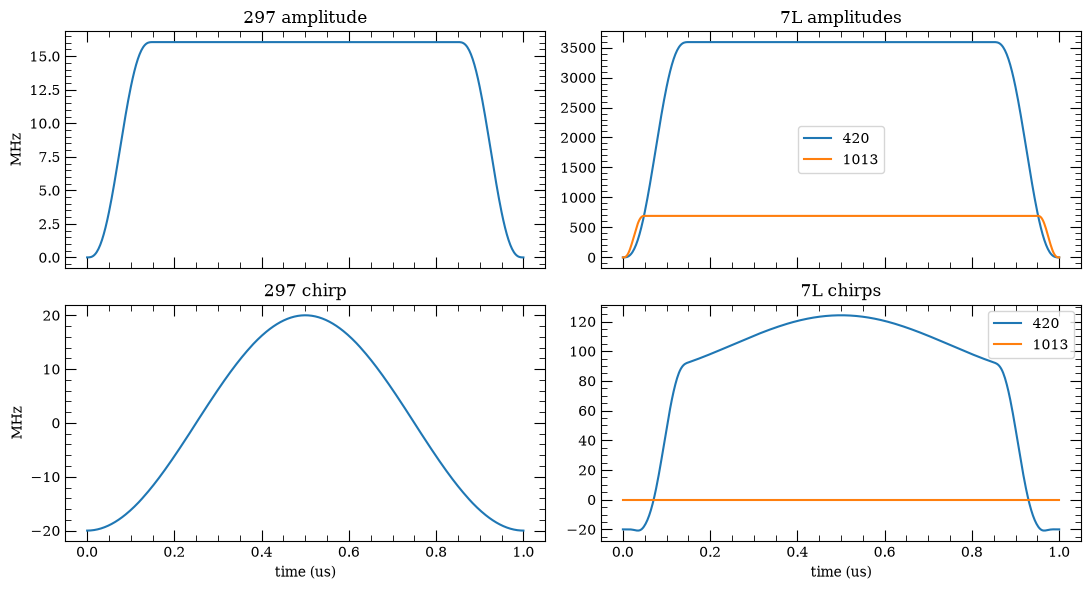

In [12]:
t_grid = np.linspace(0.0, T_AD, 500)
params297 = pulse297_ad.unpack_params([], sys297)
tr297 = [pulse297_ad.pulse_traces(float(t), params297) for t in t_grid]
params7 = pulse7_ad.unpack_params([], sys7_ad)
tr7 = [pulse7_ad.pulse_traces(float(t), params7) for t in t_grid]

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
axes[0, 0].plot(t_grid / us, np.array([tr[r'$\Omega_{297}$'] for tr in tr297]) / MHz)
axes[0, 0].set_title('297 amplitude')
axes[0, 0].set_ylabel('MHz')
axes[1, 0].plot(t_grid / us, np.array([tr[r'$\dot\phi_{297}$'] for tr in tr297]) / MHz)
axes[1, 0].set_title('297 chirp')
axes[1, 0].set_xlabel('time (us)')
axes[1, 0].set_ylabel('MHz')

axes[0, 1].plot(t_grid / us, np.array([tr[r'$\Omega_{420}$'] for tr in tr7]) / MHz, label='420')
axes[0, 1].plot(t_grid / us, np.array([tr[r'$\Omega_{1013}$'] for tr in tr7]) / MHz, label='1013')
axes[0, 1].set_title('7L amplitudes')
axes[0, 1].legend()
axes[1, 1].plot(t_grid / us, np.array([tr[r'$\dot\phi_{420}$'] for tr in tr7]) / MHz, label='420')
axes[1, 1].plot(t_grid / us, np.array([tr[r'$\dot\phi_{1013}$'] for tr in tr7]) / MHz, label='1013')
axes[1, 1].set_title('7L chirps')
axes[1, 1].set_xlabel('time (us)')
axes[1, 1].legend()
fig.tight_layout()
plt.show()


## Population and integrated-loss diagnostics

The default diagnostic plots show only `|01>` and `|11>`. `|10>` is still included in the data table and the manual local-Z phase projection; it is not assumed identical to `|01>`.

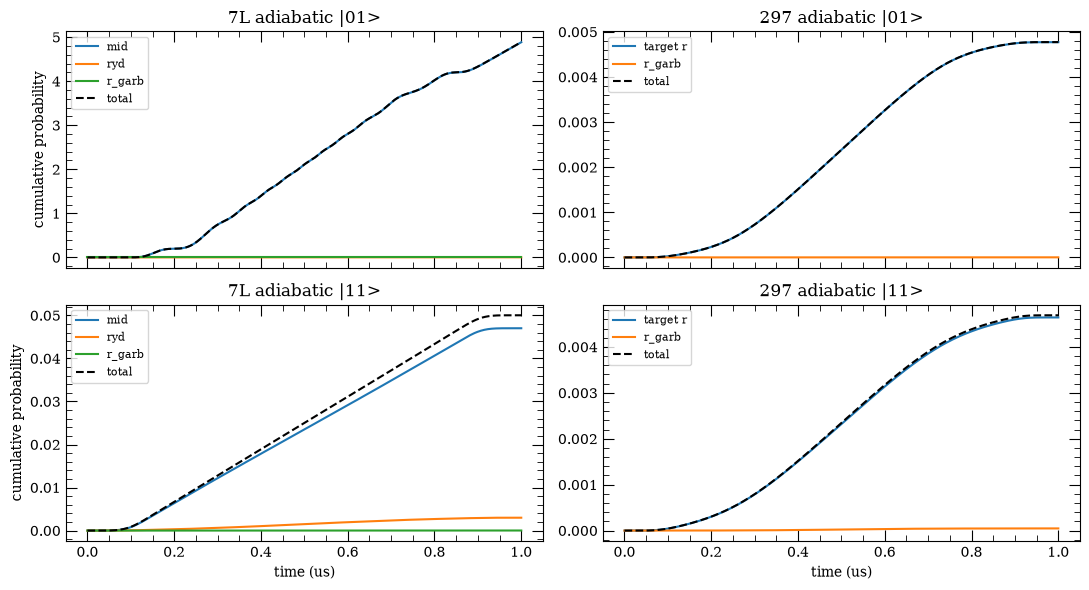

In [13]:
gamma_e7 = float(sys7_ad.meta('mid_state_decay_rate'))
gamma_r7 = float(sys7_ad.meta('ryd_state_decay_rate'))
gamma_rg7 = float(sys7_ad.meta('ryd_garb_decay_rate', gamma_r7))
gamma297 = float(sys297.meta('ryd_state_decay_rate'))

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex='col')
for row, state in enumerate(['01', '11']):
    pops7 = gate_metrics.population_evolution(sys7_ad, pulse7_ad, [], state)
    t7 = pops7['t_list']
    mid7 = cumulative_trapezoid(gamma_e7 * (pops7['e1'] + pops7['e2'] + pops7['e3']), t7, initial=0.0)
    ryd7 = cumulative_trapezoid(gamma_r7 * pops7['ryd'], t7, initial=0.0)
    rg7 = cumulative_trapezoid(gamma_rg7 * pops7['ryd_garb'], t7, initial=0.0)

    pops297 = population_evolution_297(sys297, pulse297_ad, [], state)
    t297 = pops297['t_list']
    ryd297 = cumulative_trapezoid(gamma297 * pops297['ryd'], t297, initial=0.0)
    rg297 = cumulative_trapezoid(gamma297 * pops297['ryd_garb'], t297, initial=0.0)

    ax = axes[row, 0]
    ax.plot(t7 / us, mid7, label='mid')
    ax.plot(t7 / us, ryd7, label='ryd')
    ax.plot(t7 / us, rg7, label='r_garb')
    ax.plot(t7 / us, mid7 + ryd7 + rg7, 'k--', label='total')
    ax.set_title(f'7L adiabatic |{state}>')
    ax.set_ylabel('cumulative probability')
    ax.legend(fontsize=8)

    ax = axes[row, 1]
    ax.plot(t297 / us, ryd297, label='target r')
    ax.plot(t297 / us, rg297, label='r_garb')
    ax.plot(t297 / us, ryd297 + rg297, 'k--', label='total')
    ax.set_title(f'297 adiabatic |{state}>')
    ax.legend(fontsize=8)

axes[1, 0].set_xlabel('time (us)')
axes[1, 1].set_xlabel('time (us)')
fig.tight_layout()
plt.show()


## Small one-dimensional scans

These are lightweight window checks, not optimization. They keep the fixed 297 power/area and vary either `B` or the chirp half-amplitude.

[{'B_G': 50.0,
  'D_AMP_MHz': 20.0,
  'Delta_garb_MHz': 93.30829944704605,
  'Delta_over_Omega_garb': np.float64(10.069085435893424),
  'infidelity': np.float64(0.013593492699391696),
  'theta_rad': 0.6270204352997926,
  'zz_phase_error_rad': -0.29704557723635183,
  'budget_total': 0.00675454694472516,
  'p_garb_decay': 0.0005975222845663745,
  'p_garb_residual': 0.0006118606855241023},
 {'B_G': 100.0,
  'D_AMP_MHz': 20.0,
  'Delta_garb_MHz': 186.6165988940921,
  'Delta_over_Omega_garb': np.float64(20.138170871786848),
  'infidelity': np.float64(0.5805045436910262),
  'theta_rad': 0.4182653260840943,
  'zz_phase_error_rad': -2.779098104252044,
  'budget_total': 0.0047409516296596675,
  'p_garb_decay': 1.6667631487465636e-05,
  'p_garb_residual': 6.012183364764692e-11},
 {'B_G': 150.0,
  'D_AMP_MHz': 20.0,
  'Delta_garb_MHz': 279.92489834113815,
  'Delta_over_Omega_garb': np.float64(30.20725630768027),
  'infidelity': np.float64(0.5681006800968283),
  'theta_rad': 0.3422276067496255,
  

[{'B_G': 100.0,
  'D_AMP_MHz': 10.0,
  'Delta_garb_MHz': 186.6165988940921,
  'Delta_over_Omega_garb': np.float64(20.138170871786848),
  'infidelity': np.float64(0.08407154189800004),
  'theta_rad': 0.11602858578056963,
  'zz_phase_error_rad': -0.7233318476438741,
  'budget_total': 0.01744204927702074,
  'p_garb_decay': 1.2645751855003867e-05,
  'p_garb_residual': 4.1034999656006373e-11},
 {'B_G': 100.0,
  'D_AMP_MHz': 20.0,
  'Delta_garb_MHz': 186.6165988940921,
  'Delta_over_Omega_garb': np.float64(20.138170871786848),
  'infidelity': np.float64(0.5805045436910262),
  'theta_rad': 0.4182653260840943,
  'zz_phase_error_rad': -2.779098104252044,
  'budget_total': 0.0047409516296596675,
  'p_garb_decay': 1.6667631487465636e-05,
  'p_garb_residual': 6.012183364764692e-11},
 {'B_G': 100.0,
  'D_AMP_MHz': 40.0,
  'Delta_garb_MHz': 186.6165988940921,
  'Delta_over_Omega_garb': np.float64(20.138170871786848),
  'infidelity': np.float64(0.006692500824039493),
  'theta_rad': -1.354159546254493

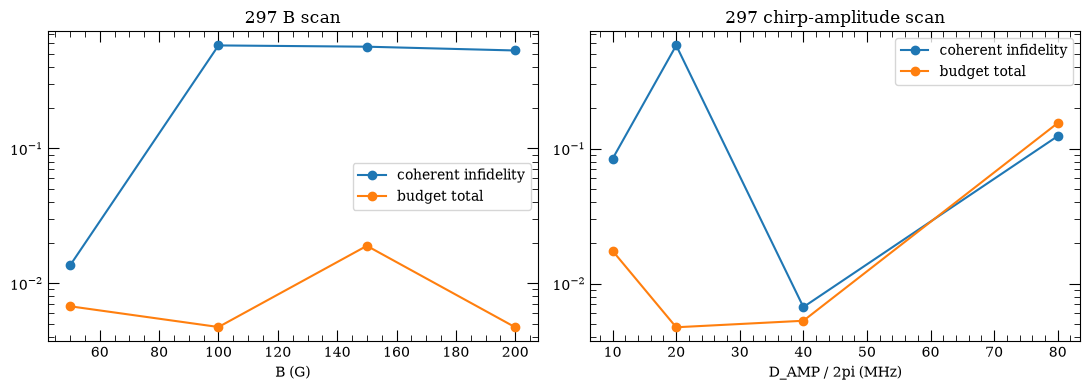

In [14]:
scan_rows_B, scan_rows_D = [], []
if RUN_SCANS:
    for rows_out, points in (
        (scan_rows_B, [(b, D_AMP) for b in (50.0, 100.0, 150.0, 200.0)]),
        (scan_rows_D, [(B_FIELD_G, d * MHz) for d in (10.0, 20.0, 40.0, 80.0)]),
    ):
        for B_G, d_amp in points:
            system = (
                RydbergSystem.set_atom_level(
                    'rb87_297_clock_4',
                    enable_rydberg_decay=False,
                    magnetic_field_G=float(B_G),
                    ryd_level=RYD_LEVEL_297,
                )
                .set_atom_geom(Register.chain(2, spacing_um=SPACING_UM))
            )
            pulse = make_297_adiabatic(d_amp=d_amp, n_steps=N_STEPS_SCAN)

            # Manual local-Z phase projection, same as the main 297 block.
            results = rg.simulate(system.with_protocol(pulse), [], cfgs, backend='exact_dense')
            states = {s: system.product_state(s) for s in labels}
            u = {s: complex(np.vdot(states[s], results[i].psi_final)) for i, s in enumerate(labels)}
            phi = {s: float(np.angle(u[s])) for s in labels}
            theta_a = wrap_to_pi(phi['10'] - phi['00'])
            theta_b = wrap_to_pi(phi['01'] - phi['00'])
            zz = wrap_to_pi(phi['11'] - phi['10'] - phi['01'] + phi['00'])
            a00 = u['00'] * np.exp(-1j * phi['00'])
            a01 = u['01'] * np.exp(-1j * phi['01'])
            a10 = u['10'] * np.exp(-1j * phi['10'])
            a11 = u['11'] * np.exp(-1j * (phi['10'] + phi['01'] - phi['00'] + np.pi))
            F_avg = (
                abs(a00 + a01 + a10 + a11) ** 2
                + abs(a00) ** 2 + abs(a01) ** 2 + abs(a10) ** 2 + abs(a11) ** 2
            ) / 20

            budget = error_budget_297(system, pulse, [], initial_states=['01', '10', '11'])
            rows_out.append({
                'B_G': float(B_G),
                'D_AMP_MHz': d_amp / MHz,
                'Delta_garb_MHz': system.meta('garb_zeeman_detuning') / MHz,
                'Delta_over_Omega_garb': abs(system.meta('garb_zeeman_detuning')) / omega297_garb,
                'infidelity': 1.0 - F_avg,
                'theta_rad': 0.5 * wrap_to_pi(theta_a + theta_b),
                'zz_phase_error_rad': wrap_to_pi(zz - np.pi),
                'budget_total': budget['p_total'],
                'p_garb_decay': budget['p_garb_decay'],
                'p_garb_residual': budget['p_garb_residual'],
            })

scan_B = pd.DataFrame(scan_rows_B) if pd is not None else scan_rows_B
scan_D = pd.DataFrame(scan_rows_D) if pd is not None else scan_rows_D
display(scan_B)
display(scan_D)

if RUN_SCANS:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot([r['B_G'] for r in scan_rows_B], [r['infidelity'] for r in scan_rows_B],
                 marker='o', label='coherent infidelity')
    axes[0].plot([r['B_G'] for r in scan_rows_B], [r['budget_total'] for r in scan_rows_B],
                 marker='o', label='budget total')
    axes[0].set_yscale('log')
    axes[0].set_xlabel('B (G)')
    axes[0].legend()
    axes[0].set_title('297 B scan')

    axes[1].plot([r['D_AMP_MHz'] for r in scan_rows_D], [r['infidelity'] for r in scan_rows_D],
                 marker='o', label='coherent infidelity')
    axes[1].plot([r['D_AMP_MHz'] for r in scan_rows_D], [r['budget_total'] for r in scan_rows_D],
                 marker='o', label='budget total')
    axes[1].set_yscale('log')
    axes[1].set_xlabel('D_AMP / 2pi (MHz)')
    axes[1].legend()
    axes[1].set_title('297 chirp-amplitude scan')
    fig.tight_layout()
    plt.show()


## Decay-on sanity check

This is intentionally off by default. The main report uses trajectory-integrated budgets because some exact backends renormalize piecewise evolution, making non-Hermitian norm loss backend-dependent.

In [15]:
if RUN_DECAY_ON_SANITY:
    decay_rows = []
    for label, pulse in [
        ('297 adiabatic seed', pulse297_ad),
        ('297 TO seed, unoptimized', pulse297_to_seed),
    ]:
        row = {'case': label}
        for column, system in [
            ('coherent_infidelity', sys297),
            ('decay_on_infidelity', sys297_decay),
        ]:
            # Manual local-Z phase projection, same as the main 297 block.
            results = rg.simulate(system.with_protocol(pulse), [], cfgs, backend='exact_dense')
            states = {s: system.product_state(s) for s in labels}
            u = {s: complex(np.vdot(states[s], results[i].psi_final)) for i, s in enumerate(labels)}
            phi = {s: float(np.angle(u[s])) for s in labels}
            a00 = u['00'] * np.exp(-1j * phi['00'])
            a01 = u['01'] * np.exp(-1j * phi['01'])
            a10 = u['10'] * np.exp(-1j * phi['10'])
            a11 = u['11'] * np.exp(-1j * (phi['10'] + phi['01'] - phi['00'] + np.pi))
            F_avg = (
                abs(a00 + a01 + a10 + a11) ** 2
                + abs(a00) ** 2 + abs(a01) ** 2 + abs(a10) ** 2 + abs(a11) ** 2
            ) / 20
            row[column] = 1.0 - F_avg
        row['delta'] = row['decay_on_infidelity'] - row['coherent_infidelity']
        decay_rows.append(row)
else:
    decay_rows = [{
        'case': 'disabled',
        'note': 'Set RUN_DECAY_ON_SANITY=True to run non-Hermitian 297 checks.',
    }]

decay_sanity = pd.DataFrame(decay_rows) if pd is not None else decay_rows
decay_sanity


[{'case': 'disabled',
  'note': 'Set RUN_DECAY_ON_SANITY=True to run non-Hermitian 297 checks.'}]